In [1]:
## 패키지 installation
! pip install -q pytorch-crf
! pip install -q gensim fsspec datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.1 MB/s eta 0:00:00


In [2]:
## 필요 라이브러리 import
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from datasets import load_dataset
from torchcrf import CRF  # import from pytorch crf
import gensim.downloader  # import from gensim
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence

In [3]:
## 개체명 인식 데이터(conll2003) 다운로드 및 데이터 구조 훑어보기
data = load_dataset("lukasgarbas/conll-03")

# 데이터 정의
train_data = data['train']
dev_data = data['validation']
test_data = data['test']

print("Data type: ", type(data))    # 데이터 타입 확인
print("Data structure: ", data)     # 데이터 구조 확인
print("Data keys: ", data.keys())   # 데이터 키 확인

print("Data 0: ", train_data[0])   # 실제 데이터 확인
print("Data class label: ", train_data.features['ner_tags'].feature)    # 데이터 레이블 확인
num_labels = train_data.features['ner_tags'].feature.num_classes   # num_labels 변수에 처리할 레이블 개수 저장
print(num_labels)

# 레이블 인덱스를 문자열 레이블로 바꾸는 딕셔너리 선언 (Ex: 3 --> B-ORG / 0 --> O / 1 --> B-PER)
label_itos = {}
for i in range(num_labels):
  label_itos[i] = train_data.features['ner_tags'].feature.int2str(i)

# Padding label idx 설정
label_itos[num_labels] = "<PAD_L>"
label_pad_idx = num_labels
print(label_itos)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


README.md:   0%|          | 0.00/819 [00:00<?, ?B/s]

data/train.parquet:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

data/validation.parquet:   0%|          | 0.00/292k [00:00<?, ?B/s]

data/test.parquet:   0%|          | 0.00/263k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

Data type:  <class 'datasets.dataset_dict.DatasetDict'>
Data structure:  DatasetDict({
    train: Dataset({
        features: ['tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})
Data keys:  dict_keys(['train', 'validation', 'test'])
Data 0:  {'tokens': ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], 'pos_tags': [22, 42, 16, 21, 35, 37, 16, 21, 7], 'chunk_tags': [11, 21, 11, 12, 21, 22, 11, 12, 0], 'ner_tags': [3, 0, 7, 0, 0, 0, 7, 0, 0]}
Data class label:  ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC'])
9
{0: 'O', 1: 'B-PER', 2: 'I-PER', 3: 'B-ORG', 4: 'I-ORG', 5: 'B-LOC', 6: 'I-LOC', 7: 'B-MISC', 8: 'I-MISC', 9: '<PAD_L>'}


In [4]:
## Gensim 라이브러리를 사용해서 워드 임베딩 불러오기
print(list(gensim.downloader.info()['models'].keys()))
embeddings = gensim.downloader.load('glove-wiki-gigaword-50')

# load한 embedding 관련 변수
emb_words = embeddings.index_to_key
emb_vectors = embeddings.vectors
emb_dim = embeddings.vector_size
emb_stoi = {key: i for i, key in enumerate(emb_words)}

# pad 인덱스: 0 / unk 인덱스 : 1 설정
emb_stoi['<pad>'] = 0
emb_stoi['<unk>'] = 1

# <pad> 단어와 <unk> 단어에 0으로 이루어진 벡터 부여
emb_vectors = np.concatenate((np.zeros(shape=(2, emb_dim)), emb_vectors), axis=0)

# 사전 학습 된 워드 임베딩에 등록되어있는 단어에 인덱스 부여
for i, word in enumerate(emb_words):
  emb_stoi[word] = i + 2

# 임베딩 벡터를 텐서 자료형으로 변환
emb_vectors = torch.cuda.FloatTensor(emb_vectors)

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']
[==================================================] 100.0% 66.0/66.0MB downloaded


/tmp/ipykernel_1563/1032397118.py:23: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  emb_vectors = torch.cuda.FloatTensor(emb_vectors)


In [5]:
## Batch 단위로 패딩하기 위한 코드 구현
# 데이터 class 선언
class CoNLLDataset(Dataset):
  def __init__(self, dataset, emb_stoi):
    self.sentences = []
    for sample in dataset:
      word_list = [token.lower() for token in sample["tokens"]]
      self.sentences.append(word_list)
    self.labels = [sample['ner_tags'] for sample in dataset]
    self.emb_stoi = emb_stoi

  def __len__(self):
    return len(self.sentences)

  def __getitem__(self, idx):
    indexed_sentence = [self.emb_stoi.get(word, self.emb_stoi['<unk>']) for word in self.sentences[idx]]
    sentence_tensor = torch.tensor(indexed_sentence, dtype=torch.long)
    label_tensor = torch.tensor(self.labels[idx], dtype=torch.long)
    return sentence_tensor, label_tensor

# 배치에서 가장 긴 시퀀스 길이에 맞추는 데이터 로더
def collate_batch(batch):
  sentences, labels = zip(*batch)
  sentences_padded = pad_sequence(sentences, batch_first=True, padding_value=emb_stoi['<pad>'])
  labels_padded = pad_sequence([torch.tensor(l, dtype=torch.long) for l in labels], batch_first=True, padding_value= num_labels)
  return sentences_padded, labels_padded

train_dataset = CoNLLDataset(train_data, emb_stoi)
dev_dataset = CoNLLDataset(dev_data, emb_stoi)
test_dataset = CoNLLDataset(test_data, emb_stoi)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=False, collate_fn=collate_batch)
dev_loader = DataLoader(dev_dataset, batch_size=128, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, collate_fn=collate_batch)


In [6]:
## NER 평가 코드
def evaluate_iob(predictions, labels, itos, label_pad_idx):
  true_positives = 0
  all_predictions = 0
  all_answers = 0

  for preds, targets in zip(predictions, labels):
    # Get predicted named entities
    preds_string = [itos[int(index)] for index in preds if int(index) != label_pad_idx]
    pred_entities = get_entities(preds_string)

    # Get target(answer) named entities
    targets_string = [itos[int(index)] for index in targets if int(index) != label_pad_idx]
    target_entities = get_entities(targets_string)

    # Count all predictions and all targetst(answers)
    all_predictions += len(pred_entities)
    all_answers += len(target_entities)

    # Calculate true positives
    for entity in pred_entities:
      if entity in target_entities:
        true_positives += 1
        target_entities.remove(entity)

  # Calculate precision, recall, and F1 score
  precision = true_positives / (all_predictions + 1e-10)
  recall = true_positives / (all_answers + 1e-10)
  f1_score = 2 * (precision * recall) / (precision + recall + 1e-10)

  return precision*100, recall*100, f1_score*100

def get_entities(seq):
  """Gets entities from sequence.

  Args:
      seq (list): sequence of labels.

  Returns:
      list: list of (chunk_type, chunk_start, chunk_end).

  Example:
      >>> from seqeval.metrics.sequence_labeling import get_entities
      >>> seq = ['B-PER', 'I-PER', 'O', 'B-LOC']
      >>> get_entities(seq)
      [('PER', 0, 1), ('LOC', 3, 3)]
  """
  # for nested list
  if any(isinstance(s, list) for s in seq):
      seq = [item for sublist in seq for item in sublist + ['O']]

  prev_tag = 'O'
  prev_type = ''
  begin_offset = 0
  chunks = []
  for i, chunk in enumerate(seq + ['O']):
      tag = chunk[0]
      type_ = chunk.split('-')[-1]

      if end_of_chunk(prev_tag, tag, prev_type, type_):
          chunks.append((prev_type, begin_offset, i-1))
      if start_of_chunk(prev_tag, tag, prev_type, type_):
          begin_offset = i
      prev_tag = tag
      prev_type = type_

  return chunks

def end_of_chunk(prev_tag, tag, prev_type, type_):
  """Checks if a chunk ended between the previous and current word.

  Args:
      prev_tag: previous chunk tag.
      tag: current chunk tag.
      prev_type: previous type.
      type_: current type.

  Returns:
      chunk_end: boolean.
  """
  chunk_end = False

  if prev_tag == 'B' and tag == 'B': chunk_end = True
  if prev_tag == 'B' and tag == 'O': chunk_end = True
  if prev_tag == 'I' and tag == 'B': chunk_end = True
  if prev_tag == 'I' and tag == 'O': chunk_end = True

  if prev_tag != 'O' and prev_tag != '.' and prev_type != type_:
      chunk_end = True

  return chunk_end

def start_of_chunk(prev_tag, tag, prev_type, type_):
  """Checks if a chunk started between the previous and current word.

  Args:
      prev_tag: previous chunk tag.
      tag: current chunk tag.
      prev_type: previous type.
      type_: current type.

  Returns:
      chunk_start: boolean.
  """
  chunk_start = False

  if tag == 'B': chunk_start = True

  if tag != 'O' and tag != '.' and prev_type != type_:
      chunk_start = True

  return chunk_start

## NER 모델 만들기

In [11]:
class LSTMNER(torch.nn.Module):
  def __init__(self, input_size, hidden_size, output_size, word_vectors, pad_word_id, label_pad_idx):
    super(LSTMNER, self).__init__()
    self.pad_word_id = pad_word_id
    self.label_pad_idx = label_pad_idx

    ### [Step 1] 레이어 선언 부분 구현
    # 1. 임베딩 레이어 선언
    self.word_embedding = nn.Embedding.from_pretrained(embeddings=word_vectors)
    # 2. BiLSTM 레이어 선언
    self.bilstm = nn.LSTM(input_size=emb_dim, hidden_size = hidden_size, bidirectional=True, batch_first=True)
    # 3. 출력 Linear layer 선언
    self.linear = nn.Linear(2*hidden_size, output_size)
    # 4. 출력 CRF layer 선언
    self.crf = CRF(output_size, batch_first=True)

  def get_lstm_outputs(self, x):
    # 1. 입력 인덱스 시퀀스를 단어 임베딩으로 만들기
    embedded_sents = self.word_embedding(x)
    # 2. 임베딩 결과를 BiLSTM에 입력 & 3. BiLSTM 시퀀스에서의 출력값을 사용
    all_hidden_states, _ = self.bilstm(embedded_sents)
    # 4. hidden state를 풀고자 하는 문제(레이블 차원의 숫자)로 변환
    outputs = self.linear(all_hidden_states)
    # 5. padded label을 위한 후처리
    pad_mask = (x == self.pad_word_id)
    outputs[:, :, self.label_pad_idx] += pad_mask * 10000
    return outputs

  ### [Step 3] CRF layer 순전파 부분 구현
  def predict(self, x):

    # 1. BiLSTM 결과 값 구하기
    lstm_outputs = self.get_lstm_outputs(x)
    # 2. CRF layer의 알고리즘에 의한 최종 출력 결과 예측
    predicted_res = self.crf.decode(lstm_outputs)

    return predicted_res

    ### [Step 4] CRF loss 계산 구현
  def get_crf_loss(self, outputs, labels):
    # 1. pytorch-crf를 사용한 crf loss 계산
    loss = self.crf(outputs, labels)
    return -loss

In [12]:
# 하이퍼파라미터 셋팅
input_size = emb_dim
hidden_size = 128
output_size = len(label_itos)
learning_rate = 0.001
batch_size = 128
num_epochs = 10

# BiLSTM NER 모델 초기화
model = LSTMNER(input_size, hidden_size, output_size, emb_vectors, emb_stoi['<pad>'], label_pad_idx)
device = torch.device("cuda") # use GPU
model = model.to(device)

# optimizer 정의
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [14]:
# dev_index를 dev_tensors로 사용
all_preds, all_labels = [], []
for dev_tensors, dev_labels in dev_loader:
  preds = model.predict(dev_tensors.to(device)) # list of list
  all_preds.extend(preds)
  all_labels.extend(dev_labels.tolist()) # tensor → list of list
dev_p, dev_r, dev_f1 = evaluate_iob(all_preds, all_labels, label_itos, label_pad_idx)
print(f"Epoch 0, Precision: {dev_p}, Recall: {dev_r}, F1-score: {dev_f1}")

# best f1 score 초기값 셋팅
best_f1 = 0

/tmp/ipykernel_1563/2658607558.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels_padded = pad_sequence([torch.tensor(l, dtype=torch.long) for l in labels], batch_first=True, padding_value= num_labels)
/usr/local/lib/python3.12/dist-packages/torchcrf/__init__.py:305: UserWarning: where received a uint8 condition tensor. This behavior is deprecated and will be removed in a future version of PyTorch. Use a boolean condition instead. (Triggered internally at /pytorch/aten/src/ATen/native/TensorCompare.cpp:614.)
  score = torch.where(mask[i].unsqueeze(1), next_score, score)


Epoch 0, Precision: 1.911204673936178, Recall: 13.598115112756417, F1-score: 3.3513760114437026


In [15]:
for epoch in range(num_epochs):
  model.train()
  epoch_loss = 0

  for batch_data, batch_labels in train_loader:
    outputs = model.get_lstm_outputs(batch_data.to(device))
    loss = model.get_crf_loss(outputs, batch_labels.to(device))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    epoch_loss += loss.item()

  # dev 평가
  model.eval()
  with torch.no_grad():
    all_preds, all_labels = [], []
    for dev_tensors, dev_labels in dev_loader:
      preds = model.predict(dev_tensors.to(device))
      all_preds.extend(preds)
      all_labels.extend(dev_labels.tolist())
    dev_p, dev_r, dev_f1 = evaluate_iob(all_preds, all_labels, label_itos, label_pad_idx)

    if dev_f1 > best_f1:
      best_model = model
      best_f1 = dev_f1

    print(f"Epoch {epoch+1}, Precision: {dev_p}, Recall: {dev_r}, F1-score: {dev_f1}, loss:{epoch_loss/len(train_loader)}")

/tmp/ipykernel_1563/2658607558.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels_padded = pad_sequence([torch.tensor(l, dtype=torch.long) for l in labels], batch_first=True, padding_value= num_labels)


Epoch 1, Precision: 31.34099616857997, Recall: 6.883204308313583, F1-score: 11.28742927812856, loss:1403.381898359819
Epoch 2, Precision: 71.34631203728897, Recall: 43.78996970716857, F1-score: 54.27051829750656, loss:731.9282001842151
Epoch 3, Precision: 75.80830084842752, Recall: 55.637832379669206, F1-score: 64.17548286418375, loss:532.7859299399636
Epoch 4, Precision: 77.85743547726182, Recall: 63.96836082127122, F1-score: 70.23281595956993, loss:432.5456921664151
Epoch 5, Precision: 80.87829854273177, Recall: 69.1181420397161, F1-score: 74.53720507669907, loss:369.2973933133212
Epoch 6, Precision: 82.07851318035118, Recall: 72.83742847525963, F1-score: 77.1823450685786, loss:323.4058535489169
Epoch 7, Precision: 83.16317059587742, Recall: 75.395489734095, F1-score: 79.08906346045327, loss:288.7587357260964
Epoch 8, Precision: 84.13566739605973, Recall: 77.65062268596301, F1-score: 80.76317170864219, loss:261.1833921952681
Epoch 9, Precision: 84.86213732203848, Recall: 79.249410972

In [17]:
# best_model을 사용하여 최종 평가
best_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
  for test_tensors, test_labels in test_loader:
    preds = best_model.predict(test_tensors.to(device))
    all_preds.extend(preds)
    all_labels.extend(test_labels.tolist())
test_p, test_r, test_f1 = evaluate_iob(all_preds, all_labels, label_itos, label_pad_idx)
print(f"Test Performance: Precision: {test_p}, Recall: {test_r}, F1-score: {test_f1}")

/tmp/ipykernel_1563/2658607558.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels_padded = pad_sequence([torch.tensor(l, dtype=torch.long) for l in labels], batch_first=True, padding_value= num_labels)


Test Performance: Precision: 82.01570202665543, Recall: 79.53257790368131, F1-score: 80.755056174775


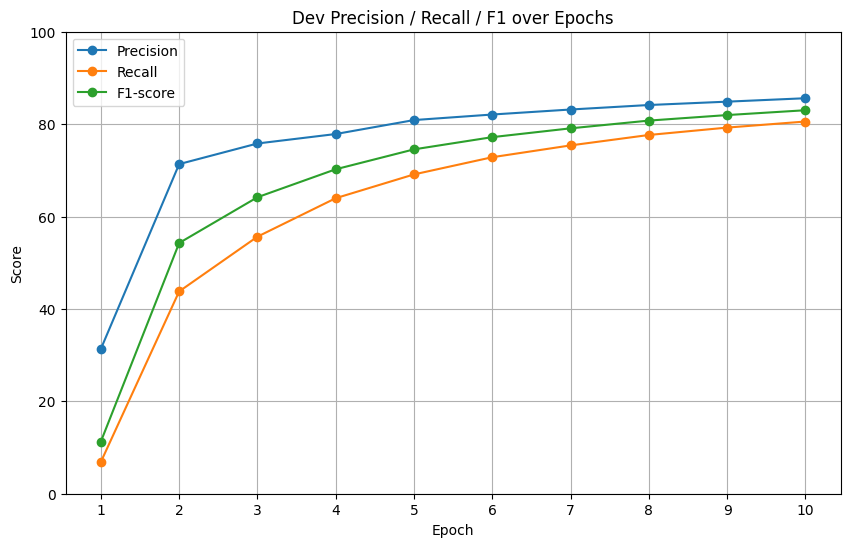

In [18]:
import matplotlib.pyplot as plt

epochs = list(range(1, 11))

precision = [
    31.3409961685797,
    71.3463120728897,
    75.8083084842752,
    77.8574354726182,
    80.8782985427177,
    82.0785318035118,
    83.1631705958742,
    84.1356739605973,
    84.8621732203848,
    85.6044349700848
]

recall = [
    6.88320430813583,
    43.7899697071687,
    55.637832379699206,
    63.9683608272712,
    69.1181420397161,
    72.8374284752963,
    75.395489734005,
    77.650622685963,
    79.249410972351,
    80.5621003029695
]

f1 = [
    11.2874292712856,
    54.27051829750656,
    64.17548286418375,
    70.228159596993,
    74.53720507669907,
    77.1823450685786,
    79.0890634604527,
    80.7637170864219,
    81.9597946168824,
    83.00676260988092
]

loss = [
    1403.381898359819,
    731.928001842151,
    532.7859293399636,
    432.5456921664151,
    369.2973933133212,
    323.405835489169,
    288.758757260964,
    261.183921952681,
    238.1978521867232,
    218.557027574019
]

plt.figure(figsize=(10, 6))

plt.plot(epochs, precision, marker="o", label="Precision")
plt.plot(epochs, recall, marker="o", label="Recall")
plt.plot(epochs, f1, marker="o", label="F1-score")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Dev Precision / Recall / F1 over Epochs")
plt.xticks(epochs)
plt.ylim(0, 100)
plt.grid(True)
plt.legend()
plt.show()

In [21]:
!python --version

Python 3.12.13


In [23]:
import torch
import numpy as np
import gensim
import datasets
import torchcrf
import sys

print("Python:", sys.version)
print("torch:", torch.__version__)
print("numpy:", np.__version__)
print("gensim:", gensim.__version__)
print("datasets:", datasets.__version__)
print("torchcrf:", torchcrf.__version__ if hasattr(torchcrf, "__version__") else "version info 없음")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
torch: 2.11.0+cu128
numpy: 2.0.2
gensim: 4.4.0
datasets: 4.0.0
torchcrf: 0.7.2
